In [13]:
# Import library here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df_train = pd.read_csv("../../data/processed/01.2/train_data.csv")


print(f"จำนวนข้อมูลทั้งหมด: {df_train.shape[0]:,} แถว")

จำนวนข้อมูลทั้งหมด: 5,469,092 แถว


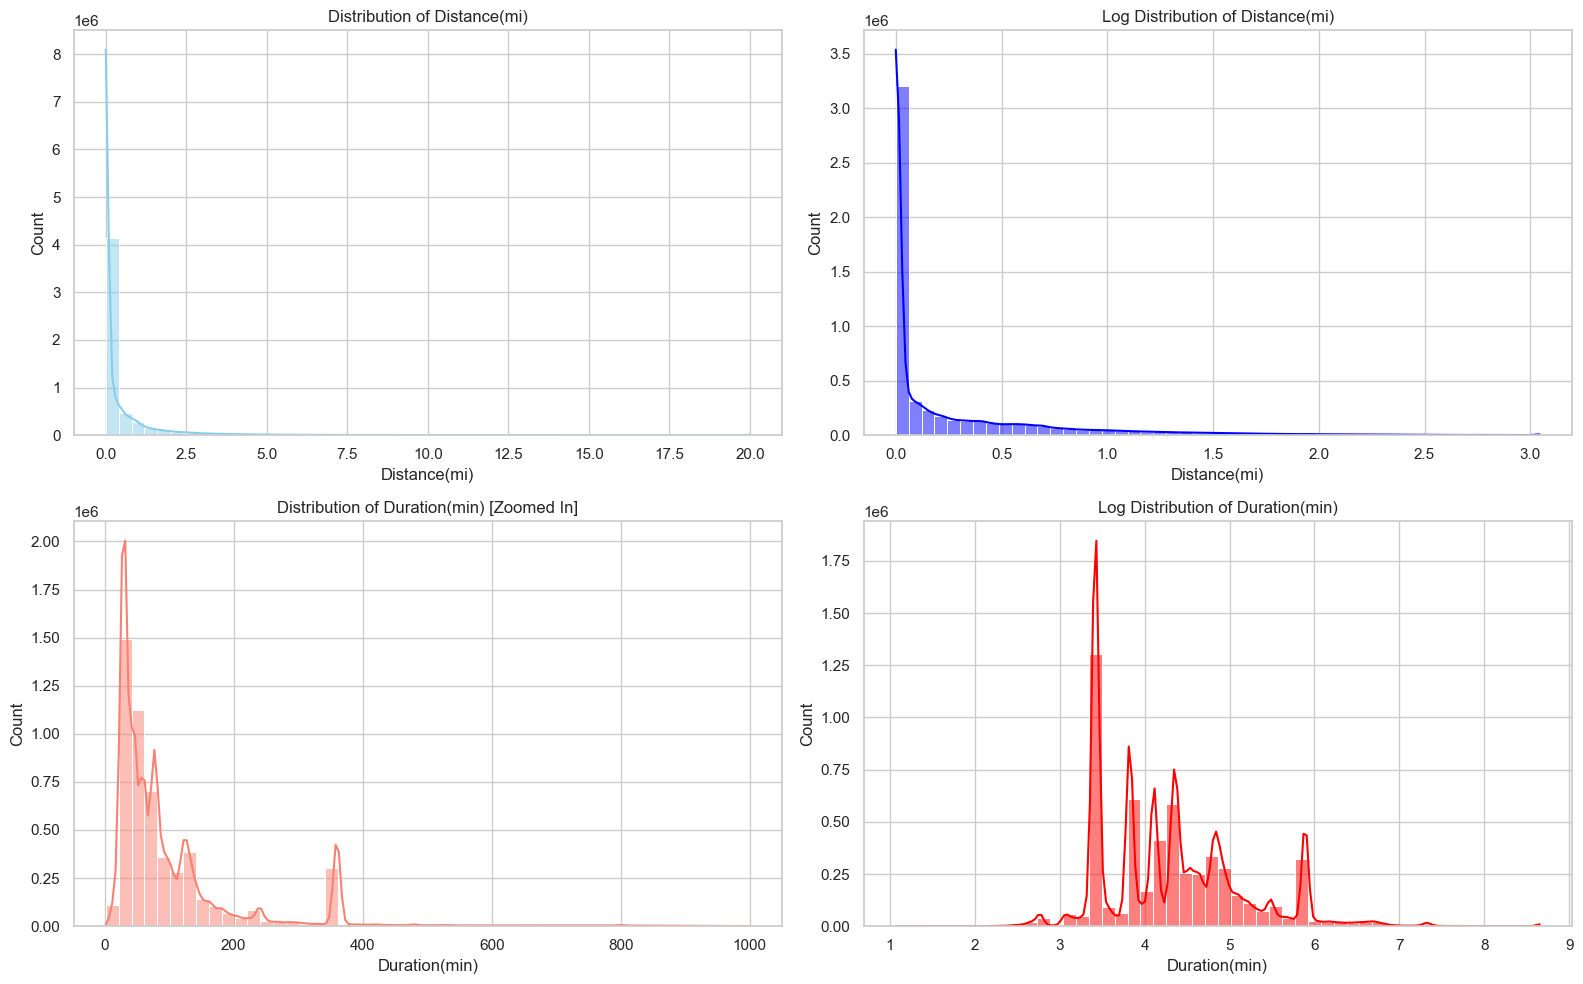

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


sns.histplot(df_train['Distance(mi)'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Distance(mi)')


sns.histplot(np.log1p(df_train['Distance(mi)']), bins=50, kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Log Distribution of Distance(mi)')


sns.histplot(df_train[df_train['Duration(min)'] < 1000]['Duration(min)'], bins=50, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution of Duration(min) [Zoomed In]')


sns.histplot(np.log1p(df_train['Duration(min)']), bins=50, kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Log Distribution of Duration(min)')

plt.tight_layout()
plt.show()

การกระจายตัวของตัวแปรเป้าหมาย (Target Distribution: Duration & Distance)
สิ่งที่ EDA บ่งบอก: กราฟ Histogram แบบปกติจะแสดงให้เห็นชัดเจนว่าข้อมูลมีลักษณะ "เบ้ขวาอย่างรุนแรง" (Highly Right-Skewed) หมายความว่าอุบัติเหตุส่วนใหญ่ใช้เวลาเคลียร์ไม่นานและมีระยะทางที่ได้รับผลกระทบสั้น แต่มีข้อมูลบางส่วน (Outliers) ที่ใช้เวลาเคลียร์นานข้ามวัน หรือกินระยะทางหลายไมล์

ผลกระทบต่อโมเดล (Implications): * หากโยนข้อมูลนี้เข้าโมเดลโดยตรง โมเดลจะพยายามไปเรียนรู้และลด Error จากกลุ่ม Outliers เหล่านี้มากเกินไป ทำให้ทำนายเคสปกติ (Majority class) พลาดไปหมด

การแก้ปัญหา: การ Take Log (ตามที่เราดูในกราฟ Log Distribution) จะดึงข้อมูลให้กลับมาใกล้เคียงการกระจายตัวแบบปกติ (Normal Distribution) มากขึ้น ช่วยให้สมการ Loss Function (เช่น RMSE) ของโมเดลทำงานได้อย่างมีเสถียรภาพ และทำให้โมเดลตระกูล Tree-based หรือ Linear เรียนรู้ได้ดีขึ้น

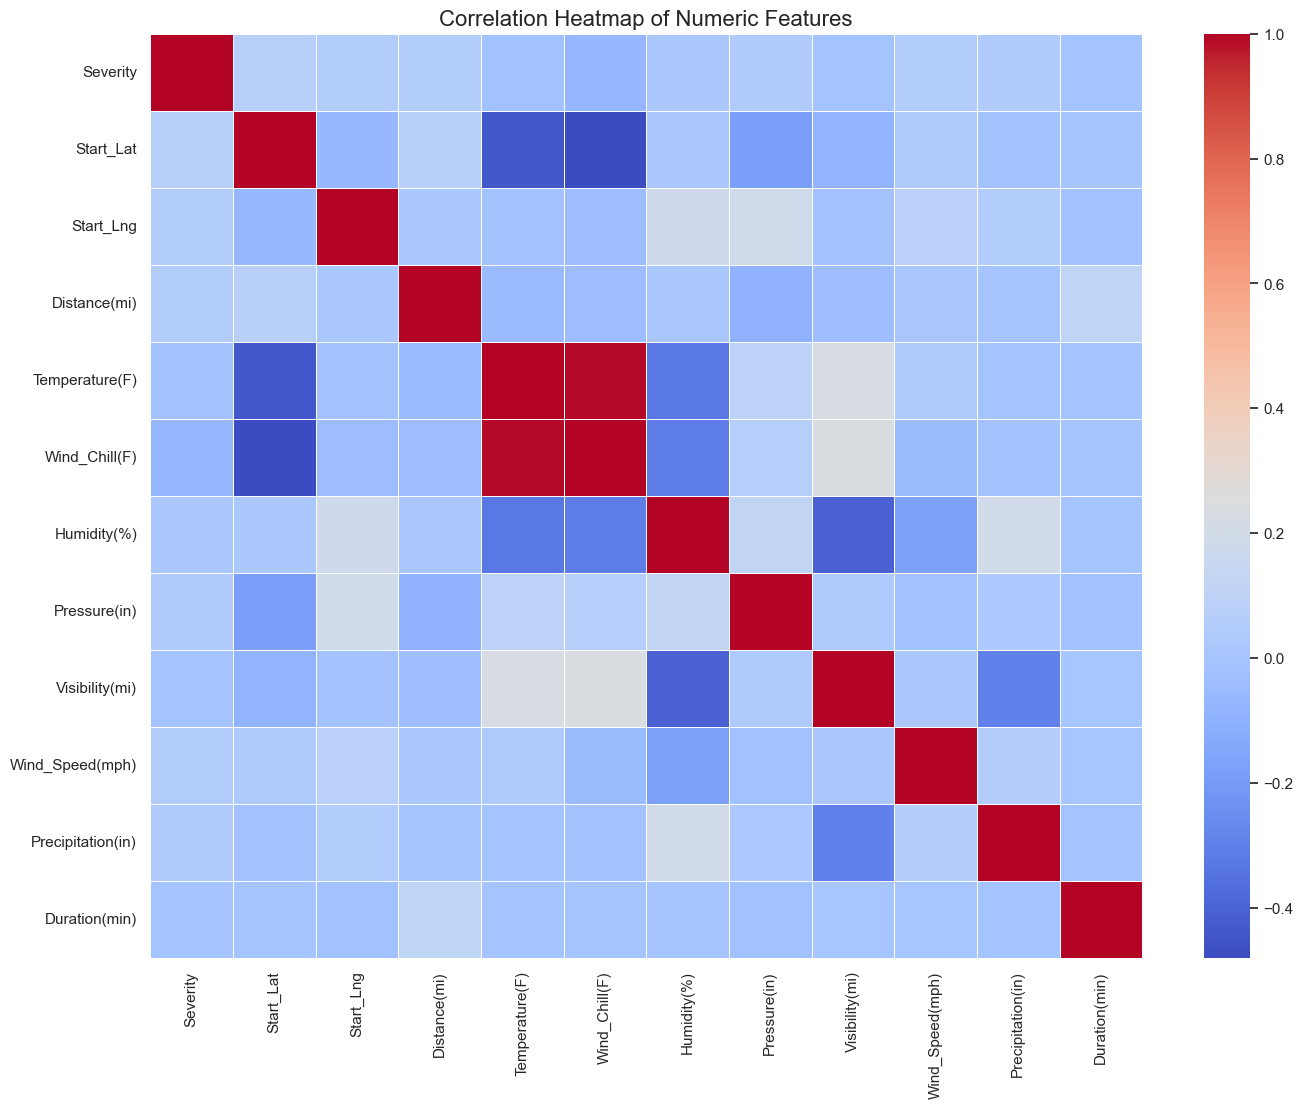

Correlation with Distance(mi):
Distance(mi)     1.000000
Duration(min)    0.109973
Start_Lat        0.071606
Severity         0.051811
Start_Lng        0.017380
Name: Distance(mi), dtype: float64

Correlation with Duration(min):
Duration(min)      1.000000
Distance(mi)       0.109973
Visibility(mi)     0.003945
Wind_Speed(mph)    0.001218
Wind_Chill(F)     -0.002030
Name: Duration(min), dtype: float64


In [16]:
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = df_train[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()

print("Correlation with Distance(mi):")
print(corr_matrix['Distance(mi)'].sort_values(ascending=False).head(5))
print("\nCorrelation with Duration(min):")
print(corr_matrix['Duration(min)'].sort_values(ascending=False).head(5))

ความสัมพันธ์ระหว่างตัวแปรตัวเลข (Correlation Heatmap)
สิ่งที่ EDA บ่งบอก: แผนภาพความร้อนช่วยให้เราเห็นความสัมพันธ์เชิงเส้นตรง (Linear Relationship) ทั้งระหว่าง "ตัวแปรต้นกับตัวแปรตาม" และ "ตัวแปรต้นด้วยกันเอง"

ผลกระทบต่อโมเดล (Implications):

ปัญหา Multicollinearity: หากพบว่าตัวแปรต้นบางตัวมีความสัมพันธ์กันเองสูงเกินไป (เช่น Temperature กับ Wind_Chill) โมเดลอาจจะสับสนและให้น้ำหนักความสำคัญ (Feature Importance) คลาดเคลื่อน การรู้สิ่งนี้ช่วยให้เราตัดสินใจ "ตัด" ตัวแปรที่ซ้ำซ้อนทิ้งไปได้ เพื่อลดความซับซ้อน (Dimensionality Reduction) และทำให้โมเดลเทรนเร็วขึ้น

หากตัวแปรต้นมีความสัมพันธ์แบบเส้นตรงกับ Target น้อยมาก นั่นเป็นสัญญาณบอกว่าเราอาจจะต้องใช้โมเดลที่ซับซ้อนขึ้นอย่าง Random Forest หรือ XGBoost ที่จับความสัมพันธ์แบบ Non-linear ได้ดีกว่า Linear Regression

C:\Users\Asus\AppData\Local\Temp\ipykernel_32080\3981701219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Severity', y='Duration(min)', ax=axes[0], palette='Set2')
C:\Users\Asus\AppData\Local\Temp\ipykernel_32080\3981701219.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Severity', y='Distance(mi)', ax=axes[1], palette='Set2')


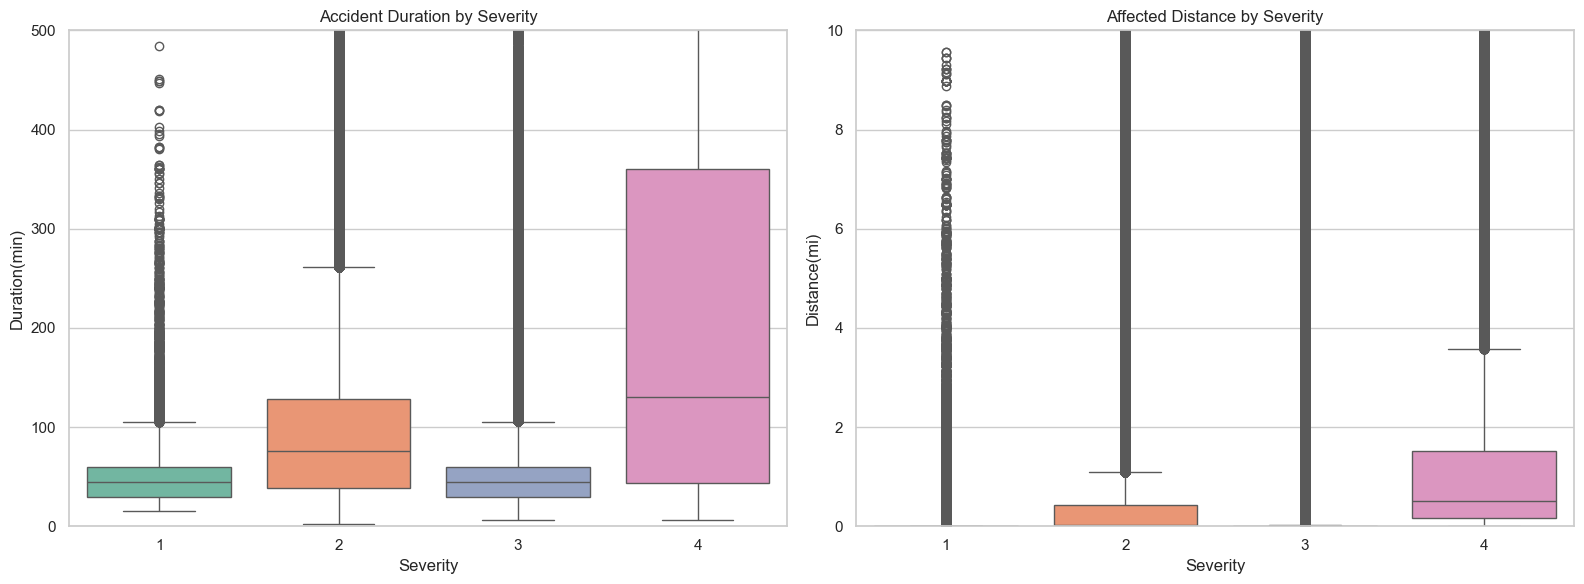

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_train, x='Severity', y='Duration(min)', ax=axes[0], palette='Set2')
axes[0].set_ylim(0, 500) 
axes[0].set_title('Accident Duration by Severity')

sns.boxplot(data=df_train, x='Severity', y='Distance(mi)', ax=axes[1], palette='Set2')
axes[1].set_ylim(0, 10) 
axes[1].set_title('Affected Distance by Severity')

plt.tight_layout()
plt.show()

ผลกระทบของความรุนแรง (Severity vs Target)
สิ่งที่ EDA บ่งบอก: กราฟ Boxplot ช่วยยืนยันสมมติฐานเบื้องต้นของเราว่า อุบัติเหตุที่มี Severity ระดับ 4 (รุนแรงสุด) มีค่ามัธยฐาน (Median) ของระยะเวลาเคลียร์ถนนและการกินระยะทางสูงกว่าระดับ 1-3 อย่างมีนัยสำคัญ

ผลกระทบต่อโมเดล (Implications):

ฟีเจอร์ Severity จะเป็น Strong Predictor (ตัวแปรที่มีความสำคัญระดับท็อป) สำหรับโมเดลนี้

เมื่อโมเดลตระกูล Decision Tree เริ่มทำการแบ่งกิ่ง (Splitting) มันมีแนวโน้มที่จะหยิบตัวแปรนี้มาเป็นเงื่อนไขแรกๆ ในการแยกกลุ่มข้อมูลที่เบาและหนักออกจากกัน ทำให้เรามั่นใจได้ว่าข้อมูลคอลัมน์นี้คลีนและพร้อมใช้งาน

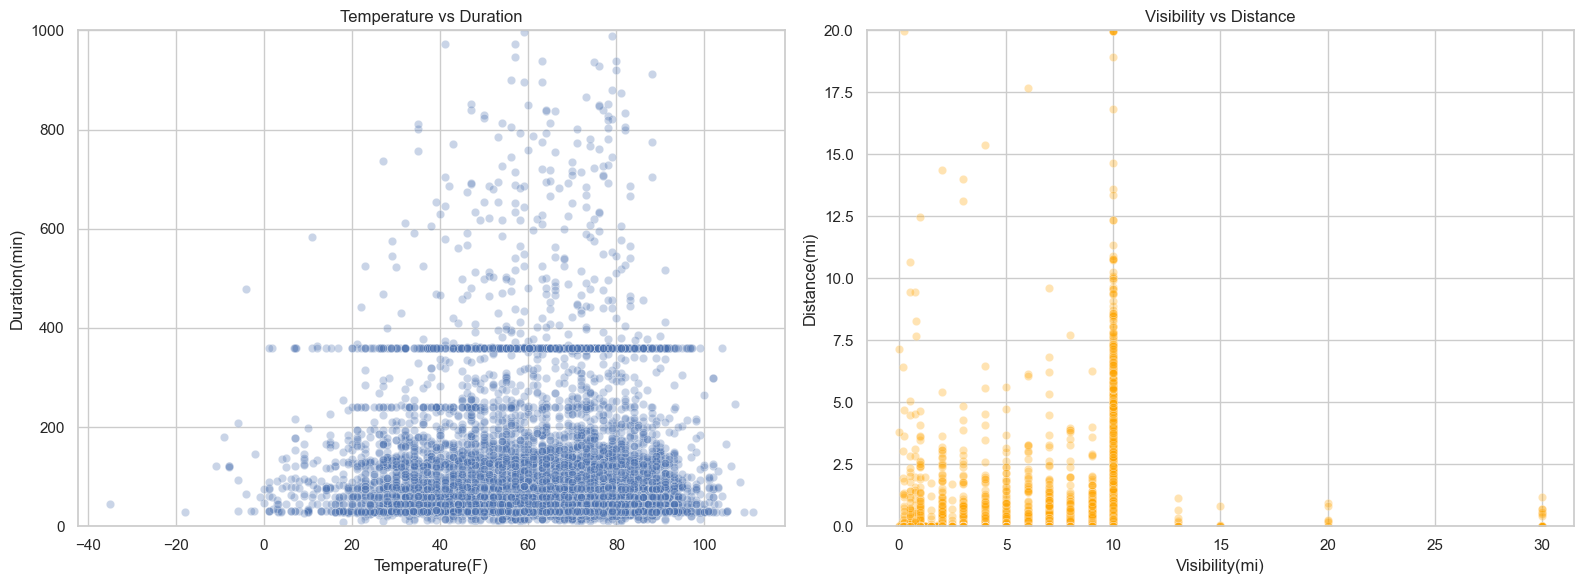

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_sample = df_train.sample(n=10000, random_state=42)

sns.scatterplot(data=df_sample, x='Temperature(F)', y='Duration(min)', alpha=0.3, ax=axes[0])
axes[0].set_ylim(0, 1000)
axes[0].set_title('Temperature vs Duration')

sns.scatterplot(data=df_sample, x='Visibility(mi)', y='Distance(mi)', alpha=0.3, color='orange', ax=axes[1])
axes[1].set_ylim(0, 20)
axes[1].set_title('Visibility vs Distance')

plt.tight_layout()
plt.show()

ปัจจัยทางสภาพอากาศ (Weather Scatter Plots)
สิ่งที่ EDA บ่งบอก: การกระจายตัวของจุดข้อมูลอาจแสดงให้เห็นว่า ในสภาวะที่ทัศนวิสัย (Visibility) ต่ำ หรืออุณหภูมิต่ำจัดๆ (หิมะตก/น้ำแข็งเกาะ) จะมีแนวโน้มพบกลุ่มจุดที่ระยะเวลาเคลียร์ลากยาวขึ้น แต่ข้อมูลในภาพรวมอาจจะดูกระจัดกระจายและมี Noise สูง

ผลกระทบต่อโมเดล (Implications):

บอกให้เรารู้ว่าการใช้ตัวเลขสภาพอากาศดิบๆ อาจจะไม่ทรงพลังพอ และเป็นตัวจุดประกายให้เราต้องทำ Feature Engineering ในหัวข้อก่อนหน้า (จัดกลุ่มสภาพอากาศเป็น Snow, Rain, Low Visibility) เพื่อรวบยอดข้อมูลให้โมเดลมองเห็น Pattern ได้ง่ายขึ้น แทนที่จะให้โมเดลไปงมหาความสัมพันธ์จากตัวเลขจุดทศนิยมที่ยิบย่อย

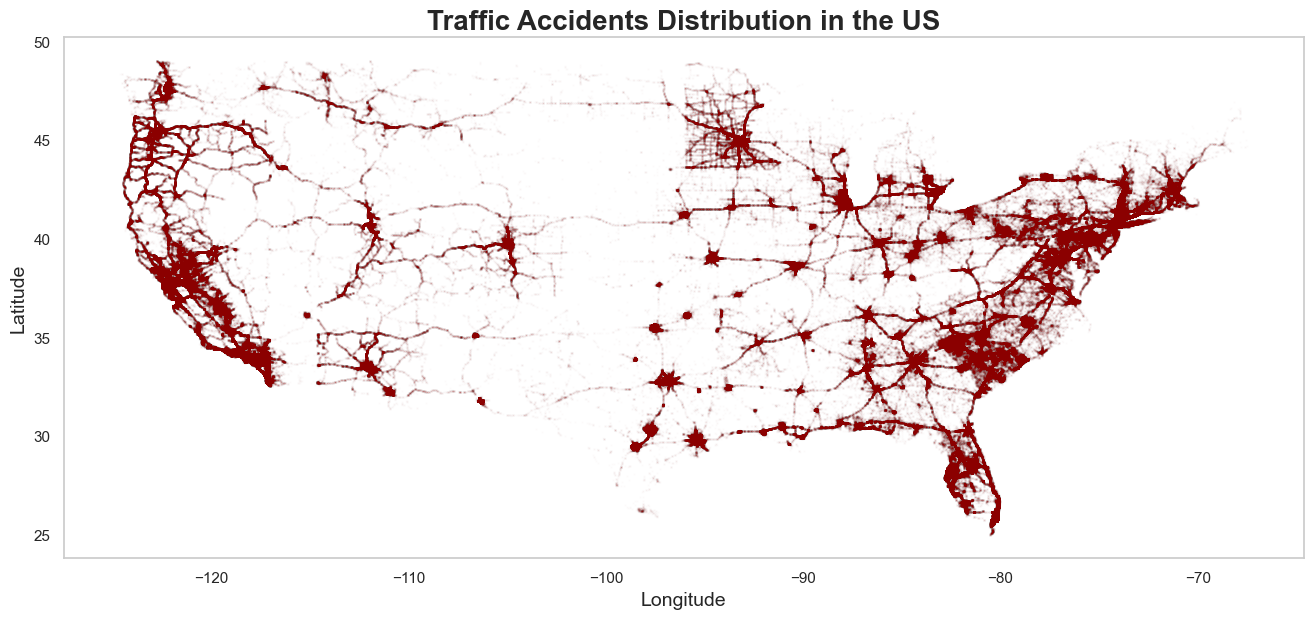

In [19]:
import matplotlib.pyplot as plt

us_bounding_box = (
    (df_train['Start_Lng'] >= -125.0) & (df_train['Start_Lng'] <= -65.0) & 
    (df_train['Start_Lat'] >= 25.0) & (df_train['Start_Lat'] <= 50.0)
)
df_map = df_train[us_bounding_box]


plt.figure(figsize=(16, 10))

plt.scatter(
    x=df_map['Start_Lng'], 
    y=df_map['Start_Lat'], 
    color='darkred', 
    alpha=0.01,  
    s=0.5        
)

plt.title('Traffic Accidents Distribution in the US', fontsize=20, fontweight='bold')
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)


plt.gca().set_aspect('equal', adjustable='box')

plt.grid(False) 
plt.show()

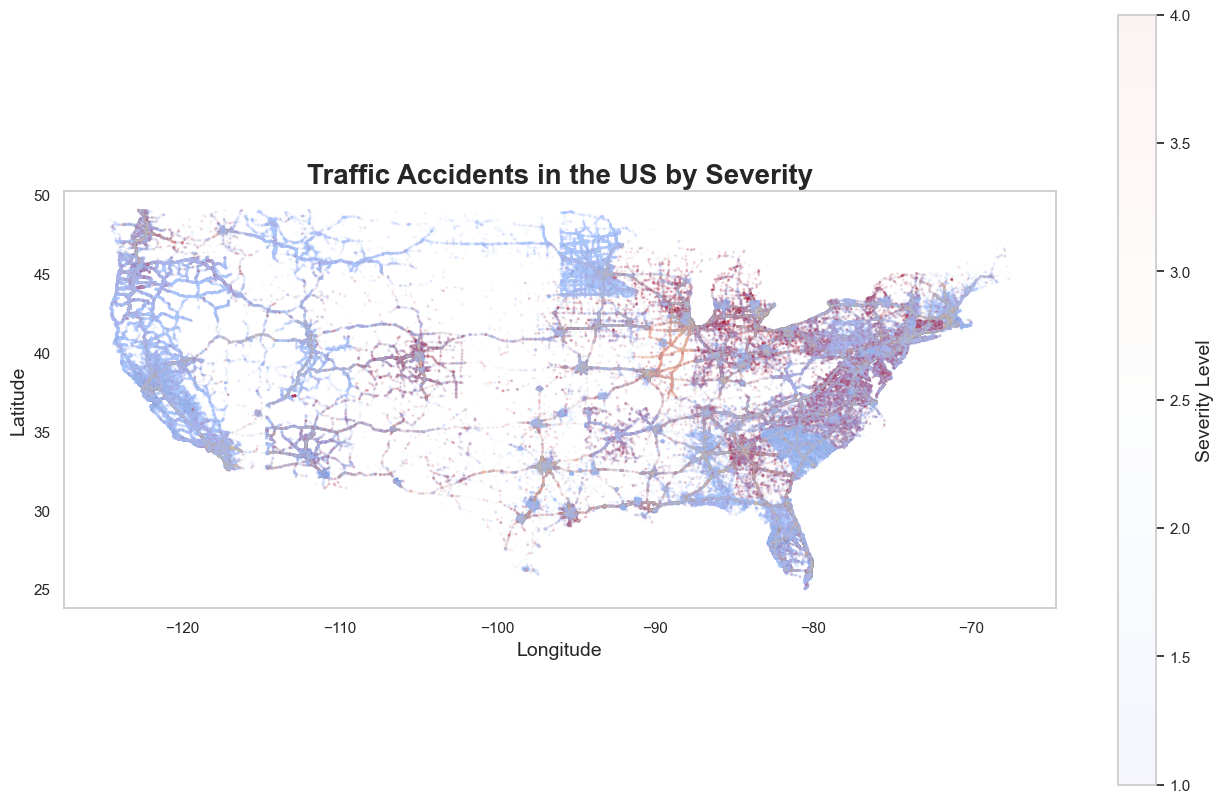

In [20]:
plt.figure(figsize=(16, 10))


scatter = plt.scatter(
    x=df_map['Start_Lng'], 
    y=df_map['Start_Lat'], 
    c=df_map['Severity'], 
    cmap='coolwarm', 
    alpha=0.05, 
    s=1
)

plt.title('Traffic Accidents in the US by Severity', fontsize=20, fontweight='bold')
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(False)

# เพิ่มแถบสีอธิบายด้านข้าง
cbar = plt.colorbar(scatter)
cbar.set_label('Severity Level', fontsize=14)

plt.show()

การกระจายตัวเชิงพื้นที่ (US Map Scatter Plot)
สิ่งที่ EDA บ่งบอก: แผนที่บ่งชี้ว่าอุบัติเหตุไม่ได้เกิดแบบสุ่ม (Random) ทั่วประเทศ แต่จะกระจุกตัวหนาแน่น (Dense Clusters) อยู่ตามเมืองใหญ่, ชายฝั่งตะวันออก/ตะวันตก, และเส้นทางหลวงสายหลัก

ผลกระทบต่อโมเดล (Implications):

ตัวแปรเชิงพื้นที่ (Spatial Features) สำคัญมาก อุบัติเหตุในเมืองใหญ่ที่มีทรัพยากรเยอะอาจจะเคลียร์ไวกว่า หรืออาจจะเคลียร์ช้ากว่าเพราะรถติดสะสม

สิ่งนี้สนับสนุนว่าทำไมเราถึงต้องแปลงข้อมูลอย่าง City หรือ State เป็น Frequency Encoding เพราะโมเดลต้องการรู้ "ความหนาแน่นของอุบัติเหตุในจุดนั้น" มากกว่าแค่รู้ "ชื่อเมือง"

In [21]:
# df_train_clean = pd.read_csv("../../data/processed/01.3/accidents_advance_clean.csv")

# df_train_clean.head(10)